# 08_优化算法-随机梯度下降法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天大家聊聊关于「随机梯度下降」的内容\~

首先，随机梯度下降（Stochastic Gradient Descent，SGD）是一种用于优化机器学习模型的算法。

它是一种迭代方法，用于最小化一个函数，通过找到该函数的最小值来优化模型参数。

随机梯度下降的工作原理是通过不断调整模型参数以最小化损失函数。

它与传统的梯度下降算法的主要区别在于：**传统梯度下降算法每次使用整个数据集来计算梯度，而随机梯度下降算法每次只使用一个样本或一个小批量（mini-batch）的样本来计算梯度。**

### 算法步骤

1. **初始化参数**：初始化模型参数（例如权重和偏置）为随机值或零值。
2. **迭代更新**：

   - 从训练集中随机选择一个样本或一个小批量的样本。
   - 计算该样本或小批量样本的梯度。
   - 使用计算出的梯度来更新模型参数，更新的方式是：参数 = 参数 - 学习率 \* 梯度。
3. **重复**：重复步骤2，直到达到预定的迭代次数或损失函数的值收敛到满意的范围。

举一个小例子，就非常容易搞明白了：

假设你想找一个山谷的最低点（最小值），但是你的视力不好，每次只能看到你脚下的情况。

你会怎么做？

1. **初始化**：你站在某个随机的地方（参数初始化）。
2. **看脚下**：你只能看到脚下这小块地的坡度（计算当前样本的梯度）。
3. **调整步伐**：根据坡度的方向，你决定往下坡的方向走一步（根据梯度更新参数），但是你每次只能走一小步（学习率）。
4. **不断重复**：你不断重复这个过程，每次走一步，慢慢地你会越来越接近最低点（优化模型参数），尽管你每次只看到了脚下的小块地，但经过多次迭代后，你最终会找到山谷的最低点。

通过这种方式，随机梯度下降在处理大规模数据集时非常有效，因为它每次只处理一个样本或一个小批量样本，从而大大减少了每次更新时的计算量。此外，随机梯度下降的随机性也帮助它跳出局部最小值，更有可能找到全局最小值。

总结来说，随机梯度下降是一种迭代优化算法，通过每次使用一个样本或一个小批量样本来更新模型参数，从而逐步最小化损失函数，使模型性能达到最优。

## 理论基础

#### 数学原理

随机梯度下降是一种用于优化目标函数 $f(\theta)$的算法，其中 $\theta$是模型的参数向量。

目标是找到使 $f(\theta)$最小化的参数值。

##### 目标函数

假设我们有一个损失函数 $L(\theta)$，定义为：


$$
L(\theta) = \frac{1}{N} \sum_{i=1}^{N} \ell(\theta; x_i, y_i)
$$


其中：

- $N$是训练样本的总数。
- $(x_i, y_i)$是第 $i$个训练样本和其对应的标签。
- $\ell(\theta; x_i, y_i)$是参数 $\theta$下第 $i$个样本的损失。

##### 梯度计算

梯度下降算法通过计算损失函数的梯度来更新参数：


$$
\nabla L(\theta) = \frac{1}{N} \sum_{i=1}^{N} \nabla \ell(\theta; x_i, y_i)
$$


其中 $\nabla \ell(\theta; x_i, y_i)$是第 $i$个样本的损失对参数 $\theta$的梯度。

##### 随机梯度下降

与传统梯度下降不同，随机梯度下降每次只使用一个样本或一个小批量的样本来估计梯度。因此，随机梯度下降的更新公式为：


$$
\theta_{t+1} = \theta_t - \eta \nabla \ell(\theta_t; x_i, y_i)
$$


其中：

- $\theta_t$是第 $t$次迭代的参数值。
- $\eta$是学习率（步长）。
- $\nabla \ell(\theta_t; x_i, y_i)$是当前随机选择的样本 $(x_i, y_i)$对参数 $\theta_t$的梯度。

#### 算法流程

1. **初始化**：

   - 选择初始参数 $\theta_0$。
   - 选择学习率 $\eta$。
2. **迭代更新**：

   - **For** $t = 0, 1, 2, \ldots, T-1$（T 是最大迭代次数）：
   
     1. 从训练集中随机选择一个样本 $(x_i, y_i)$。
     2. 计算当前样本的梯度 $\nabla \ell(\theta_t; x_i, y_i)$。
     3. 更新参数：$\theta_{t+1} = \theta_t - \eta \nabla \ell(\theta_t; x_i, y_i)$
     4. （可选）如果使用小批量梯度下降，则在每次迭代中使用一个小批量的样本而非单个样本。
3. **终止条件**：

   - 达到最大迭代次数 $T$。
   - 或者，损失函数的值收敛到预定的阈值。

#### 详细步骤

1. **初始化参数** $\theta$：

   - 通常使用随机初始化或其他策略初始化参数。
2. **选择学习率** $\eta$：

   - 学习率是一个超参数，决定了每次参数更新的步长。通常需要通过实验进行调整。
3. **迭代过程**：

   - 对于每一次迭代：
   
     1. **随机选择样本**：
     
        - 从训练集中随机选择一个样本 $(x_i, y_i)$。如果使用小批量梯度下降，则随机选择一个小批量样本 $\{(x_{i1}, y_{i1}), (x_{i2}, y_{i2}), \ldots, (x_{im}, y_{im})\}$。
     2. **计算梯度**：
     
        - 计算损失函数关于当前参数 $\theta_t$的梯度 $\nabla \ell(\theta_t; x_i, y_i)$。
        - 如果使用小批量梯度下降，则计算小批量样本的平均梯度。
     3. **更新参数**：
     
        - 更新参数 $\theta$：  
        $\theta_{t+1} = \theta_t - \eta \nabla \ell(\theta_t; x_i, y_i)$
        - 如果使用小批量梯度下降：  
        $\theta_{t+1} = \theta_t - \eta \frac{1}{m} \sum_{j=1}^{m} \nabla \ell(\theta_t; x_{ij}, y_{ij})$
     4. **检查终止条件**：
     
        - 检查是否达到最大迭代次数或损失函数是否收敛。
4. **收敛**：

   - 当算法终止时，当前的参数 $\theta$即为优化后的参数，可以用于预测或评估模型性能。

## 应用场景

#### 适用问题类型

随机梯度下降主要适用于以下类型的问题：

1. **大规模数据集的优化问题**：由于SGD在每次更新时仅使用一个样本或一个小批量样本，计算效率较高，非常适合处理大规模数据集。
2. **凸优化问题**：在凸优化问题中，SGD能保证找到全局最优解。
3. **非凸优化问题**：在深度学习等非凸优化问题中，SGD也表现良好，能够跳出局部最优，找到较优解。

### 优缺点

#### 优点

1. **高效性**：每次只使用一个样本或小批量样本计算梯度，计算速度快，适合大规模数据集。
2. **内存需求低**：由于每次只需存储一个样本或小批量样本，内存需求较低。
3. **随机性帮助跳出局部最优**：SGD的随机性可以帮助优化过程跳出局部最优，找到更好的全局最优解。

#### 缺点

1. **收敛不稳定**：由于梯度计算的随机性，收敛过程可能不稳定，容易出现震荡。
2. **需要调参**：需要仔细调整学习率，否则可能导致收敛过慢或震荡。
3. **噪声大**：每次仅使用一个样本，计算的梯度噪声较大。

### 运用前提条件

1. **适当的数据预处理**：数据应进行标准化或归一化，以确保所有特征在同一尺度上。
2. **合适的学习率**：选择适当的学习率，可能需要通过实验确定。
3. **数据要有足够的样本量**：SGD的随机性需要足够的样本量来弥补单次更新中的噪声。

### 实际应用案例

1. **机器学习模型训练**：

   - **线性回归**：使用SGD优化线性回归模型的参数，使得均方误差最小化。
   - **逻辑回归**：使用SGD优化逻辑回归模型的参数，以最小化交叉熵损失。
2. **深度学习**：

   - **神经网络训练**：在训练神经网络时，特别是深度神经网络和卷积神经网络，SGD及其变种（如SGD+Momentum、Adam）广泛使用。
3. **推荐系统**：

   - **矩阵分解**：使用SGD优化矩阵分解模型的参数，用于构建推荐系统，如Netflix的电影推荐。
4. **自然语言处理**：

   - **词向量训练**：使用SGD训练Word2Vec等词向量模型，以捕捉词汇之间的语义关系。
5. **图像分类**：

   - **卷积神经网络（CNN）训练**：在图像分类任务中，使用SGD优化CNN的参数，提高分类精度。

## 完整案例

使用SGD来训练线性回归模型，并展示一些数据分析和优化结果的可视化。

Train MSE: 0.01013296831253827
Test MSE: 0.010132282928015863


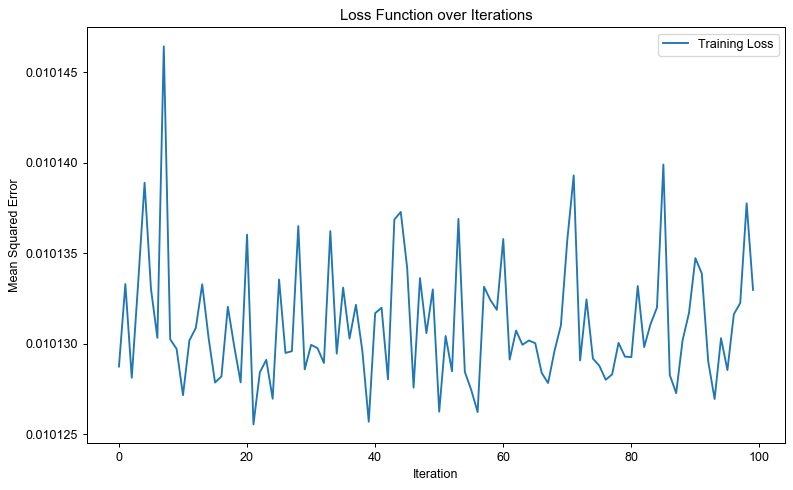

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# 生成一个大的合成数据集
X, y = make_regression(n_samples=100000, n_features=10, noise=0.1)

# 将数据集分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 数据标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class SGDRegressor:
    def __init__(self, learning_rate=0.01, n_iterations=1000, batch_size=32):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size

    def fit(self, X, y):
        self.theta = np.zeros(X.shape[1])
        self.bias = 0
        m = X.shape[0]

        self.losses = []

        for i in range(self.n_iterations):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for start in range(0, m, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                y_pred = np.dot(X_batch, self.theta) + self.bias
                error = y_pred - y_batch

                gradient_theta = (1 / self.batch_size) * np.dot(X_batch.T, error)
                gradient_bias = (1 / self.batch_size) * np.sum(error)

                self.theta -= self.learning_rate * gradient_theta
                self.bias -= self.learning_rate * gradient_bias

            # 计算损失并存储
            y_train_pred = np.dot(X, self.theta) + self.bias
            loss = mean_squared_error(y, y_train_pred)
            self.losses.append(loss)

        return self

    def predict(self, X):
        return np.dot(X, self.theta) + self.bias

sgd_regressor = SGDRegressor(learning_rate=0.01, n_iterations=100, batch_size=64)
sgd_regressor.fit(X_train, y_train)

# 预测
y_train_pred = sgd_regressor.predict(X_train)
y_test_pred = sgd_regressor.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")

# 损失函数的变化
plt.figure(figsize=(10, 6))
plt.plot(range(len(sgd_regressor.losses)), sgd_regressor.losses, label='Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Loss Function over Iterations')
plt.legend()
plt.show()

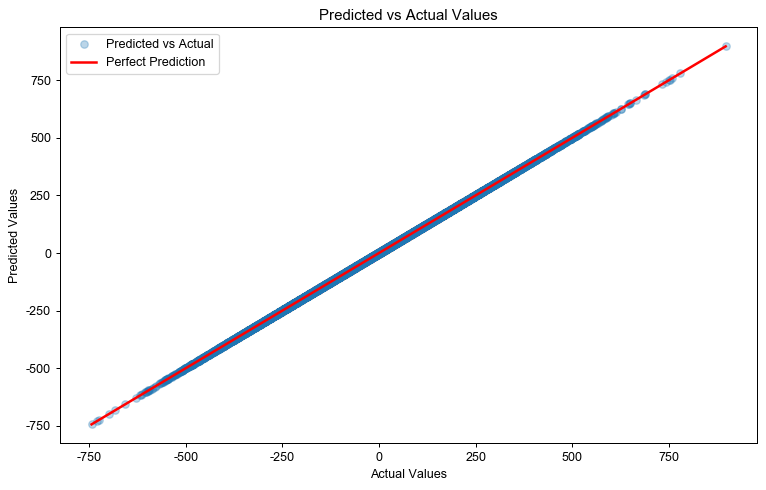

In [3]:
# 预测结果的分布
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, label='Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2, label='Perfect Prediction')
plt.legend()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_014.png)

![原文参考图，当前结果见代码输出](attachments/img_015.png)

### 算法优化

1. **学习率调整**：选择不同的学习率，观察模型的表现和收敛速度。
2. **批量大小调整**：尝试不同的批量大小（mini-batch size），观察其对模型收敛速度和稳定性的影响。
3. **增加正则化**：在损失函数中添加正则化项（L1或L2正则化），防止过拟合。

### 代码实现优化

调整学习率和批量大小：

In [4]:
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64, 128]

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training with learning rate: {lr}, batch size: {bs}")
        sgd_regressor = SGDRegressor(learning_rate=lr, n_iterations=100, batch_size=bs)
        sgd_regressor.fit(X_train, y_train)
        
        y_train_pred = sgd_regressor.predict(X_train)
        y_test_pred = sgd_regressor.predict(X_test)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        print(f"Train MSE: {train_mse}, Test MSE: {test_mse}")

Training with learning rate: 0.01, batch size: 32


Train MSE: 0.010130570774277897, Test MSE: 0.010123397011406661
Training with learning rate: 0.01, batch size: 64


Train MSE: 0.010128986290812065, Test MSE: 0.01012375813681374
Training with learning rate: 0.01, batch size: 128


Train MSE: 0.010126091374484265, Test MSE: 0.010120083371725512
Training with learning rate: 0.001, batch size: 32


Train MSE: 0.010123669780082205, Test MSE: 0.010123634075939502
Training with learning rate: 0.001, batch size: 64


Train MSE: 0.010123521520094127, Test MSE: 0.010122481498169729
Training with learning rate: 0.001, batch size: 128


Train MSE: 0.01012346093189183, Test MSE: 0.010122346694446978
Training with learning rate: 0.0001, batch size: 32


Train MSE: 0.010123452772261513, Test MSE: 0.010122375707466057
Training with learning rate: 0.0001, batch size: 64


Train MSE: 0.010123928932782909, Test MSE: 0.010121638422812421
Training with learning rate: 0.0001, batch size: 128


Train MSE: 0.14428048419455772, Test MSE: 0.14301868509383336


通过上述代码，可以调整SGD的学习率和批量大小，观察其对模型训练效果的影响，选择最佳参数组合。